## This is a sample pandas project that exemplifies how to proceed data wrangling, specifically for data science and machine learning purposes, using Python, Pandas, NumPy, Matplotlib, Seaborn and xlrd

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# xlrd is a dependence which just need to be at the environment but not imported. Basically allows importing old xls 
# files, and not only xlsx.

In [2]:
time_data = pd.read_excel('(1.2) dataset_principal.xls')
merge_data = pd.read_excel('(1.3) dataset_join.xls')

In [3]:
pd.set_option("display.max.columns", None)

In [4]:
print(time_data)

       Student  Time to get to school (minutes)  Distance to the school (Km)  \
0     Gabriela                               15                            8   
1       Dalila                               20                            6   
2      Gustavo                               20                           15   
3      Letícia                               40                           20   
4  Luiz Ovídio                               50                           25   
5       Leonor                               25                           11   
6          Ana                               10                            5   
7      Antônio                               55                           32   
8        Júlia                               35                           28   
9      Mariana                               30                           20   

   Traffic lights Period of day Driver profile  
0               0       Morning           calm  
1               1    

In [5]:
time_data.columns

Index(['Student', 'Time to get to school (minutes)',
       'Distance to the school (Km)', 'Traffic lights', 'Period of day',
       'Driver profile'],
      dtype='str')

In [6]:
time_data.head(n=5)

,Student,Time to get to school (minutes),Distance to the school (Km),Traffic lights,Period of day,Driver profile
0,Gabriela,15,8,0,Morning,calm
1,Dalila,20,6,1,Morning,moderate
2,Gustavo,20,15,0,Morning,moderate
3,Letícia,40,20,1,Afternoon,agressive
4,Luiz Ovídio,50,25,2,Afternoon,agressive


In [7]:
time_data.tail(n=3)

,Student,Time to get to school (minutes),Distance to the school (Km),Traffic lights,Period of day,Driver profile
7,Antônio,55,32,3,Afternoon,calm
8,Júlia,35,28,1,Morning,moderate
9,Mariana,30,20,1,Morning,moderate


In [8]:
time_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   Student                          10 non-null     str  
 1   Time to get to school (minutes)  10 non-null     int64
 2   Distance to the school (Km)      10 non-null     int64
 3   Traffic lights                   10 non-null     int64
 4   Period of day                    10 non-null     str  
 5   Driver profile                   10 non-null     str  
dtypes: int64(3), str(3)
memory usage: 612.0 bytes


In [9]:
time_data = time_data.rename(columns={'Student':'student',
                                          'Time to get to school (minutes)':'time',
                                          'Distance to the school (Km)': 'distance',
                                          'Traffic lights': 'traffic_lights',
                                          'Period of day': 'period',
                                          'Driver profile': 'profile'})

# could have used inplace=true
# could have used df.columns[column_number], instead of column name, but this latter is safer

In [10]:
time_data

,student,time,distance,traffic_lights,period,profile
0,Gabriela,15,8,0,Morning,calm
1,Dalila,20,6,1,Morning,moderate
2,Gustavo,20,15,0,Morning,moderate
3,Letícia,40,20,1,Afternoon,agressive
4,Luiz Ovídio,50,25,2,Afternoon,agressive
5,Leonor,25,11,1,Morning,moderate
6,Ana,10,5,0,Morning,calm
7,Antônio,55,32,3,Afternoon,calm
8,Júlia,35,28,1,Morning,moderate
9,Mariana,30,20,1,Morning,moderate


In [11]:
print(f"{time_data.iloc[3,]}\n")
print(f"{time_data.iloc[:,4]}\n")
print(f"{time_data.iloc[2:5,]}\n")
print(f"{time_data.iloc[:,3:5]}\n")
print(f"{time_data.iloc[2:4,3:5]}\n")
print(f"{time_data.iloc[5,4]}\n")

# using iloc will bring you the row, column value at that indexes' position (sequence), no matter what the index 
# labels (names) are. Here, the index names are ints from 0 to 9, but they could be string names, as well. None would 
# matter, 'cause iloc will always consider the position (sequence) of the elements at that axis (row or column), not 
# the index label (name) itself.

student             Letícia
time                     40
distance                 20
traffic_lights            1
period            Afternoon
profile           agressive
Name: 3, dtype: object

0      Morning
1      Morning
2      Morning
3    Afternoon
4    Afternoon
5      Morning
6      Morning
7    Afternoon
8      Morning
9      Morning
Name: period, dtype: str

       student  time  distance  traffic_lights     period    profile
2      Gustavo    20        15               0    Morning   moderate
3      Letícia    40        20               1  Afternoon  agressive
4  Luiz Ovídio    50        25               2  Afternoon  agressive

   traffic_lights     period
0               0    Morning
1               1    Morning
2               0    Morning
3               1  Afternoon
4               2  Afternoon
5               1    Morning
6               0    Morning
7               3  Afternoon
8               1    Morning
9               1    Morning

   traffic_lights     period
2     

In [12]:
time_data_inversed = time_data.copy()
new_index_list = []
for i in time_data.index:
    new_index_list.append(len(time_data.index)-i-1)
time_data_inversed.index = new_index_list
print(time_data_inversed)

       student  time  distance  traffic_lights     period    profile
9     Gabriela    15         8               0    Morning       calm
8       Dalila    20         6               1    Morning   moderate
7      Gustavo    20        15               0    Morning   moderate
6      Letícia    40        20               1  Afternoon  agressive
5  Luiz Ovídio    50        25               2  Afternoon  agressive
4       Leonor    25        11               1    Morning   moderate
3          Ana    10         5               0    Morning       calm
2      Antônio    55        32               3  Afternoon       calm
1        Júlia    35        28               1    Morning   moderate
0      Mariana    30        20               1    Morning   moderate


In [13]:
# we have purposely inverted the row index labels (which are ints, in this case), in order to show the difference 
# between iloc and loc. While iloc, as shown above, will always consider the index position, and not the index label, 
# with loc you have the contrary. Loc will NOT consider the index position, but the index label itself, may it be an 
# int or a string, both for rows as for columns, even if inverted or shuffled.

# using iloc to return the data at row index position 3 and column at column index position 0. Observe the row index
# label is "6" and the column index label is "student". Which are both disconsidered by the iloc, that only cares with
# the index position or sequence (not the index label or name), both for rows as for columns.
print(time_data_inversed.iloc[3,0])

# using loc to return the data at the row label "3" and column label "student". Observe that now the index position 
# is the one to be disconsidered, both for rows as for columns. Only the index label matters, with loc.
print(time_data_inversed.loc[3,'student'])

Letícia
Ana


In [14]:
print(time_data_inversed.index)
print(time_data_inversed.columns)

# both rows and columns have their own indexes (either numbers or strings)
# if you wanna get an element by its index position or sequence, regardless the index labels, use iloc; if you wanna 
# get it by the index labels (of rows and columns), use loc.
# The 'i' from iloc doesn't come from "index", as it doesn't consider the index label at all. It comes from integer, 
# which means the only type accepted as input argument, as we're only dealing with axes' positions (not labels) - 
# which are always int. Loc, on the other hand, accepts any label type, not necessarily int, as saw above. It actually
# won't accept an int if the label is string... as in the column names above.

Index([9, 8, 7, 6, 5, 4, 3, 2, 1, 0], dtype='int64')
Index(['student', 'time', 'distance', 'traffic_lights', 'period', 'profile'], dtype='str')


In [15]:
time_data['time']
time_variable = time_data['time']
time_variable

# specific variable columns can be got either by ["column_name"], as above, or by .column_name, as below.

0    15
1    20
2    20
3    40
4    50
5    25
6    10
7    55
8    35
9    30
Name: time, dtype: int64

In [16]:
time_data.profile
profile_variable = time_data.profile
profile_variable

0         calm
1     moderate
2     moderate
3    agressive
4    agressive
5     moderate
6         calm
7         calm
8     moderate
9     moderate
Name: profile, dtype: str

In [17]:
time_data_variable = time_data[['time','profile']]
time_data_variable

# more than one column or variable can be got by using double square brackets: [['column1', 'column2', etc.]]

,time,profile
0,15,calm
1,20,moderate
2,20,moderate
3,40,agressive
4,50,agressive
5,25,moderate
6,10,calm
7,55,calm
8,35,moderate
9,30,moderate


In [18]:
selection_1 = time_data.loc[:, time_data.columns.str.startswith('per')]
selection_1

# selecting column from column's start string name (gotta use loc for labels, and not iloc, as discussed above)

,period
0,Morning
1,Morning
2,Morning
3,Afternoon
4,Afternoon
5,Morning
6,Morning
7,Afternoon
8,Morning
9,Morning


In [19]:
selection_2 = time_data.loc[:, time_data.columns.str.endswith('t')]
selection_2

# selecting column from column's end string name

,student
0,Gabriela
1,Dalila
2,Gustavo
3,Letícia
4,Luiz Ovídio
5,Leonor
6,Ana
7,Antônio
8,Júlia
9,Mariana


In [20]:
age_variable = pd.Series([25,28,30,19,20,36,33,48,19,21])
time_data['age'] = age_variable
time_data

# adding a new variable (column) to the dataframe (with same number of observations)

,student,time,distance,traffic_lights,period,profile,age
0,Gabriela,15,8,0,Morning,calm,25
1,Dalila,20,6,1,Morning,moderate,28
2,Gustavo,20,15,0,Morning,moderate,30
3,Letícia,40,20,1,Afternoon,agressive,19
4,Luiz Ovídio,50,25,2,Afternoon,agressive,20
5,Leonor,25,11,1,Morning,moderate,36
6,Ana,10,5,0,Morning,calm,33
7,Antônio,55,32,3,Afternoon,calm,48
8,Júlia,35,28,1,Morning,moderate,19
9,Mariana,30,20,1,Morning,moderate,21


In [21]:
new_observation = pd.DataFrame({'profile': ['calm'],
                         'student': ['Roberto'],
                         'time': [40]})

if new_observation.student.iloc[0] not in time_data.student.values:
    time_data = pd.concat([time_data, new_observation]).reset_index(drop=True)
time_data

# adding a new observation (with incomplete data, to generate NaN values)

,student,time,distance,traffic_lights,period,profile,age
0,Gabriela,15,8.0,0.0,Morning,calm,25.0
1,Dalila,20,6.0,1.0,Morning,moderate,28.0
2,Gustavo,20,15.0,0.0,Morning,moderate,30.0
3,Letícia,40,20.0,1.0,Afternoon,agressive,19.0
4,Luiz Ovídio,50,25.0,2.0,Afternoon,agressive,20.0
5,Leonor,25,11.0,1.0,Morning,moderate,36.0
6,Ana,10,5.0,0.0,Morning,calm,33.0
7,Antônio,55,32.0,3.0,Afternoon,calm,48.0
8,Júlia,35,28.0,1.0,Morning,moderate,19.0
9,Mariana,30,20.0,1.0,Morning,moderate,21.0


In [22]:
time_data['traffic_lights_per_km'] = round((time_data['traffic_lights'] / time_data['distance']), 2)
time_data

# adding a new variable (column) deriving from two existent other variables

,student,time,distance,traffic_lights,period,profile,age,traffic_lights_per_km
0,Gabriela,15,8.0,0.0,Morning,calm,25.0,0.00
1,Dalila,20,6.0,1.0,Morning,moderate,28.0,0.17
2,Gustavo,20,15.0,0.0,Morning,moderate,30.0,0.00
3,Letícia,40,20.0,1.0,Afternoon,agressive,19.0,0.05
4,Luiz Ovídio,50,25.0,2.0,Afternoon,agressive,20.0,0.08
5,Leonor,25,11.0,1.0,Morning,moderate,36.0,0.09
6,Ana,10,5.0,0.0,Morning,calm,33.0,0.00
7,Antônio,55,32.0,3.0,Afternoon,calm,48.0,0.09
8,Júlia,35,28.0,1.0,Morning,moderate,19.0,0.04
9,Mariana,30,20.0,1.0,Morning,moderate,21.0,0.05


In [23]:
labels = {'calm': 'A_profile',
          'moderate': 'B_profile',
          'agressive': 'C_profile'}

df_labels = time_data.assign(profile_2 = time_data.profile.map(labels))
df_labels

# adding a new str variable (column) mapped from an existent other variable

,student,time,distance,traffic_lights,period,profile,age,traffic_lights_per_km,profile_2
0,Gabriela,15,8.0,0.0,Morning,calm,25.0,0.00,A_profile
1,Dalila,20,6.0,1.0,Morning,moderate,28.0,0.17,B_profile
2,Gustavo,20,15.0,0.0,Morning,moderate,30.0,0.00,B_profile
3,Letícia,40,20.0,1.0,Afternoon,agressive,19.0,0.05,C_profile
4,Luiz Ovídio,50,25.0,2.0,Afternoon,agressive,20.0,0.08,C_profile
5,Leonor,25,11.0,1.0,Morning,moderate,36.0,0.09,B_profile
6,Ana,10,5.0,0.0,Morning,calm,33.0,0.00,A_profile
7,Antônio,55,32.0,3.0,Afternoon,calm,48.0,0.09,A_profile
8,Júlia,35,28.0,1.0,Morning,moderate,19.0,0.04,B_profile
9,Mariana,30,20.0,1.0,Morning,moderate,21.0,0.05,B_profile


In [24]:
numbers = {'calm': '1',
          'moderate': '2',
          'agressive': '3'}

df_labels = df_labels.assign(profile_3 = time_data.profile.map(numbers))
df_labels

# adding a new number variable (column) mapped from an existent other variable

,student,time,distance,traffic_lights,period,profile,age,traffic_lights_per_km,profile_2,profile_3
0,Gabriela,15,8.0,0.0,Morning,calm,25.0,0.00,A_profile,1
1,Dalila,20,6.0,1.0,Morning,moderate,28.0,0.17,B_profile,2
2,Gustavo,20,15.0,0.0,Morning,moderate,30.0,0.00,B_profile,2
3,Letícia,40,20.0,1.0,Afternoon,agressive,19.0,0.05,C_profile,3
4,Luiz Ovídio,50,25.0,2.0,Afternoon,agressive,20.0,0.08,C_profile,3
5,Leonor,25,11.0,1.0,Morning,moderate,36.0,0.09,B_profile,2
6,Ana,10,5.0,0.0,Morning,calm,33.0,0.00,A_profile,1
7,Antônio,55,32.0,3.0,Afternoon,calm,48.0,0.09,A_profile,1
8,Júlia,35,28.0,1.0,Morning,moderate,19.0,0.04,B_profile,2
9,Mariana,30,20.0,1.0,Morning,moderate,21.0,0.05,B_profile,2


In [25]:
df_labels.info()

<class 'pandas.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student                11 non-null     str    
 1   time                   11 non-null     int64  
 2   distance               10 non-null     float64
 3   traffic_lights         10 non-null     float64
 4   period                 10 non-null     str    
 5   profile                11 non-null     str    
 6   age                    10 non-null     float64
 7   traffic_lights_per_km  10 non-null     float64
 8   profile_2              11 non-null     str    
 9   profile_3              11 non-null     str    
dtypes: float64(4), int64(1), str(5)
memory usage: 1012.0 bytes


In [26]:
texts = {'1': 'one',
          '2': 'two',
          '3': 'three'}

df_labels = df_labels.assign(profile_3 = df_labels.profile_3.map(texts))
df_labels

# updating an existent number variable (column) for a stringuified correspondent one
# observe the numbers used at profile_3 above were str already, not int... the mapping must obey the types

,student,time,distance,traffic_lights,period,profile,age,traffic_lights_per_km,profile_2,profile_3
0,Gabriela,15,8.0,0.0,Morning,calm,25.0,0.00,A_profile,one
1,Dalila,20,6.0,1.0,Morning,moderate,28.0,0.17,B_profile,two
2,Gustavo,20,15.0,0.0,Morning,moderate,30.0,0.00,B_profile,two
3,Letícia,40,20.0,1.0,Afternoon,agressive,19.0,0.05,C_profile,three
4,Luiz Ovídio,50,25.0,2.0,Afternoon,agressive,20.0,0.08,C_profile,three
5,Leonor,25,11.0,1.0,Morning,moderate,36.0,0.09,B_profile,two
6,Ana,10,5.0,0.0,Morning,calm,33.0,0.00,A_profile,one
7,Antônio,55,32.0,3.0,Afternoon,calm,48.0,0.09,A_profile,one
8,Júlia,35,28.0,1.0,Morning,moderate,19.0,0.04,B_profile,two
9,Mariana,30,20.0,1.0,Morning,moderate,21.0,0.05,B_profile,two


In [27]:
time_data['time_category'] = np.where(time_data['time']<=20, 'fast',
                       np.where((time_data['time']>20) & (time_data['time']<=40), 'moderate',
                       np.where(time_data['time']>40, 'delayed',
                                'other')))
time_data

# adding a new category variable (column) mapped from an existent quantitative variable
# unlike assign / map, this example uses criterial mapping instead, with detailed analysis before setting the new 
# value

,student,time,distance,traffic_lights,period,profile,age,traffic_lights_per_km,time_category
0,Gabriela,15,8.0,0.0,Morning,calm,25.0,0.00,fast
1,Dalila,20,6.0,1.0,Morning,moderate,28.0,0.17,fast
2,Gustavo,20,15.0,0.0,Morning,moderate,30.0,0.00,fast
3,Letícia,40,20.0,1.0,Afternoon,agressive,19.0,0.05,moderate
4,Luiz Ovídio,50,25.0,2.0,Afternoon,agressive,20.0,0.08,delayed
5,Leonor,25,11.0,1.0,Morning,moderate,36.0,0.09,moderate
6,Ana,10,5.0,0.0,Morning,calm,33.0,0.00,fast
7,Antônio,55,32.0,3.0,Afternoon,calm,48.0,0.09,delayed
8,Júlia,35,28.0,1.0,Morning,moderate,19.0,0.04,moderate
9,Mariana,30,20.0,1.0,Morning,moderate,21.0,0.05,moderate


In [28]:
time_data['time_quartiles'] = pd.qcut(time_data['time'], q=4, labels=['1','2','3','4'])
time_data

# categorization by using quartiles
# if any variable needed to be set as a caegory type, we just gotta use .astype('category') on it. Here, all 
# qualitative variables are already set as qualitative. All quantitative variables are also set as quantitative.

,student,time,distance,traffic_lights,period,profile,age,traffic_lights_per_km,time_category,time_quartiles
0,Gabriela,15,8.0,0.0,Morning,calm,25.0,0.00,fast,1
1,Dalila,20,6.0,1.0,Morning,moderate,28.0,0.17,fast,1
2,Gustavo,20,15.0,0.0,Morning,moderate,30.0,0.00,fast,1
3,Letícia,40,20.0,1.0,Afternoon,agressive,19.0,0.05,moderate,3
4,Luiz Ovídio,50,25.0,2.0,Afternoon,agressive,20.0,0.08,delayed,4
5,Leonor,25,11.0,1.0,Morning,moderate,36.0,0.09,moderate,2
6,Ana,10,5.0,0.0,Morning,calm,33.0,0.00,fast,1
7,Antônio,55,32.0,3.0,Afternoon,calm,48.0,0.09,delayed,4
8,Júlia,35,28.0,1.0,Morning,moderate,19.0,0.04,moderate,3
9,Mariana,30,20.0,1.0,Morning,moderate,21.0,0.05,moderate,2


In [29]:
if "traffic_lights_per_km" in time_data.columns.values:
    time_data.drop(columns=['traffic_lights_per_km'], inplace=True)
time_data

# excluding variables (columns)

,student,time,distance,traffic_lights,period,profile,age,time_category,time_quartiles
0,Gabriela,15,8.0,0.0,Morning,calm,25.0,fast,1
1,Dalila,20,6.0,1.0,Morning,moderate,28.0,fast,1
2,Gustavo,20,15.0,0.0,Morning,moderate,30.0,fast,1
3,Letícia,40,20.0,1.0,Afternoon,agressive,19.0,moderate,3
4,Luiz Ovídio,50,25.0,2.0,Afternoon,agressive,20.0,delayed,4
5,Leonor,25,11.0,1.0,Morning,moderate,36.0,moderate,2
6,Ana,10,5.0,0.0,Morning,calm,33.0,fast,1
7,Antônio,55,32.0,3.0,Afternoon,calm,48.0,delayed,4
8,Júlia,35,28.0,1.0,Morning,moderate,19.0,moderate,3
9,Mariana,30,20.0,1.0,Morning,moderate,21.0,moderate,2


In [30]:
result1_df = time_data.sort_values(by=['time'], ascending=True).reset_index(drop=True)

result2_df = time_data.sort_values(by=['time'], ascending=False).reset_index(drop=True)

result3_df = time_data.sort_values(by=['student'], ascending=True).reset_index(drop=True)

result4_df = time_data.sort_values(by=['profile'], ascending=False).reset_index(drop=True)

result5_df = time_data.sort_values(by=['profile', 'distance'], ascending=[False, True]).reset_index(drop=True)

In [31]:
result1_df

# sorted ascending by time

,student,time,distance,traffic_lights,period,profile,age,time_category,time_quartiles
0,Ana,10,5.0,0.0,Morning,calm,33.0,fast,1
1,Gabriela,15,8.0,0.0,Morning,calm,25.0,fast,1
2,Gustavo,20,15.0,0.0,Morning,moderate,30.0,fast,1
3,Dalila,20,6.0,1.0,Morning,moderate,28.0,fast,1
4,Leonor,25,11.0,1.0,Morning,moderate,36.0,moderate,2
5,Mariana,30,20.0,1.0,Morning,moderate,21.0,moderate,2
6,Júlia,35,28.0,1.0,Morning,moderate,19.0,moderate,3
7,Letícia,40,20.0,1.0,Afternoon,agressive,19.0,moderate,3
8,Roberto,40,NaN,NaN,NaN,calm,NaN,moderate,3
9,Luiz Ovídio,50,25.0,2.0,Afternoon,agressive,20.0,delayed,4


In [32]:
result2_df

# sorted descending by time

,student,time,distance,traffic_lights,period,profile,age,time_category,time_quartiles
0,Antônio,55,32.0,3.0,Afternoon,calm,48.0,delayed,4
1,Luiz Ovídio,50,25.0,2.0,Afternoon,agressive,20.0,delayed,4
2,Roberto,40,NaN,NaN,NaN,calm,NaN,moderate,3
3,Letícia,40,20.0,1.0,Afternoon,agressive,19.0,moderate,3
4,Júlia,35,28.0,1.0,Morning,moderate,19.0,moderate,3
5,Mariana,30,20.0,1.0,Morning,moderate,21.0,moderate,2
6,Leonor,25,11.0,1.0,Morning,moderate,36.0,moderate,2
7,Dalila,20,6.0,1.0,Morning,moderate,28.0,fast,1
8,Gustavo,20,15.0,0.0,Morning,moderate,30.0,fast,1
9,Gabriela,15,8.0,0.0,Morning,calm,25.0,fast,1


In [33]:
result3_df

# sorted ascending by student

,student,time,distance,traffic_lights,period,profile,age,time_category,time_quartiles
0,Ana,10,5.0,0.0,Morning,calm,33.0,fast,1
1,Antônio,55,32.0,3.0,Afternoon,calm,48.0,delayed,4
2,Dalila,20,6.0,1.0,Morning,moderate,28.0,fast,1
3,Gabriela,15,8.0,0.0,Morning,calm,25.0,fast,1
4,Gustavo,20,15.0,0.0,Morning,moderate,30.0,fast,1
5,Júlia,35,28.0,1.0,Morning,moderate,19.0,moderate,3
6,Leonor,25,11.0,1.0,Morning,moderate,36.0,moderate,2
7,Letícia,40,20.0,1.0,Afternoon,agressive,19.0,moderate,3
8,Luiz Ovídio,50,25.0,2.0,Afternoon,agressive,20.0,delayed,4
9,Mariana,30,20.0,1.0,Morning,moderate,21.0,moderate,2


In [34]:
result4_df

# sorted descending by profile

,student,time,distance,traffic_lights,period,profile,age,time_category,time_quartiles
0,Dalila,20,6.0,1.0,Morning,moderate,28.0,fast,1
1,Gustavo,20,15.0,0.0,Morning,moderate,30.0,fast,1
2,Leonor,25,11.0,1.0,Morning,moderate,36.0,moderate,2
3,Júlia,35,28.0,1.0,Morning,moderate,19.0,moderate,3
4,Mariana,30,20.0,1.0,Morning,moderate,21.0,moderate,2
5,Gabriela,15,8.0,0.0,Morning,calm,25.0,fast,1
6,Ana,10,5.0,0.0,Morning,calm,33.0,fast,1
7,Antônio,55,32.0,3.0,Afternoon,calm,48.0,delayed,4
8,Roberto,40,NaN,NaN,NaN,calm,NaN,moderate,3
9,Letícia,40,20.0,1.0,Afternoon,agressive,19.0,moderate,3


In [35]:
result5_df

# sorted descending by profile and ascending by distance

,student,time,distance,traffic_lights,period,profile,age,time_category,time_quartiles
0,Dalila,20,6.0,1.0,Morning,moderate,28.0,fast,1
1,Leonor,25,11.0,1.0,Morning,moderate,36.0,moderate,2
2,Gustavo,20,15.0,0.0,Morning,moderate,30.0,fast,1
3,Mariana,30,20.0,1.0,Morning,moderate,21.0,moderate,2
4,Júlia,35,28.0,1.0,Morning,moderate,19.0,moderate,3
5,Ana,10,5.0,0.0,Morning,calm,33.0,fast,1
6,Gabriela,15,8.0,0.0,Morning,calm,25.0,fast,1
7,Antônio,55,32.0,3.0,Afternoon,calm,48.0,delayed,4
8,Roberto,40,NaN,NaN,NaN,calm,NaN,moderate,3
9,Letícia,40,20.0,1.0,Afternoon,agressive,19.0,moderate,3


In [36]:
time_data.describe()

# basic descriptive stats

,time,distance,traffic_lights,age
count,11.000000,10.000000,10.000000,10.000000
mean,30.909091,17.000000,1.000000,27.900000
std,14.459976,9.510228,0.942809,9.290975
min,10.000000,5.000000,0.000000,19.000000
25%,20.000000,8.750000,0.250000,20.250000
50%,30.000000,17.500000,1.000000,26.500000
75%,40.000000,23.750000,1.000000,32.250000
max,55.000000,32.000000,3.000000,48.000000


In [37]:
print(time_data["time"].count())
print(time_data["time"].mean())
print(time_data["time"].median())
print(time_data["time"].min())
print(time_data["time"].max())
print(time_data["time"].std())
print(time_data["time"].var())
print(time_data["time"].quantile())
print(time_data["time"].sum())

11
30.90909090909091
30.0
10
55
14.459976109624424
209.0909090909091
30.0
340


In [38]:
time_data[["time","distance","traffic_lights"]].corr()

# Pearson's correlation matrix

,time,distance,traffic_lights
time,1.000000,0.905221,0.909155
distance,0.905221,1.000000,0.755914
traffic_lights,0.909155,0.755914,1.000000


In [39]:
print(time_data['period'].value_counts())
print("")
print(time_data['profile'].value_counts(normalize=True))

# frequency table - qualitative variables - absolute and relative

period
Morning      7
Afternoon    3
Name: count, dtype: int64

profile
moderate     0.454545
calm         0.363636
agressive    0.181818
Name: proportion, dtype: float64


In [40]:
print(pd.crosstab(time_data['period'], time_data['profile']))
print("")
print(pd.crosstab(time_data['period'], time_data['profile'], normalize=True))

# cross-frequency table - qualitative variables - absolute and relative

profile    agressive  calm  moderate
period                              
Afternoon          2     1         0
Morning            0     2         5

profile    agressive  calm  moderate
period                              
Afternoon        0.2   0.1       0.0
Morning          0.0   0.2       0.5


In [41]:
print(time_data['time'].unique())
print("")
print(time_data['period'].unique())
print("")
print(time_data['profile'].nunique())

# unique and number of unique observations

[15 20 40 50 25 10 55 35 30]

<StringArray>
['Morning', 'Afternoon', nan]
Length: 3, dtype: str

3


In [42]:
period_grouped_df = time_data.groupby(['period'])
period_grouped_df.describe().T

# grouping data by the variable period and using basic descriptive stats as aggregation functions of the data at 
# each group. Showing the transposed output for better visualization

period                Afternoon    Morning
time           count   3.000000   7.000000
               mean   48.333333  22.142857
               std     7.637626   8.591247
               min    40.000000  10.000000
               25%    45.000000  17.500000
               50%    50.000000  20.000000
               75%    52.500000  27.500000
               max    55.000000  35.000000
distance       count   3.000000   7.000000
               mean   25.666667  13.285714
               std     6.027714   8.360907
               min    20.000000   5.000000
               25%    22.500000   7.000000
               50%    25.000000  11.000000
               75%    28.500000  17.500000
               max    32.000000  28.000000
traffic_lights count   3.000000   7.000000
               mean    2.000000   0.571429
               std     1.000000   0.534522
               min     1.000000   0.000000
               25%     1.500000   0.000000
               50%     2.000000   1.000000
               75%     2.500000   1.000000
               max     3.000000   1.000000
age            count   3.000000   7.000000
               mean   29.000000  27.428571
               std    16.462078   6.187545
               min    19.000000  19.000000
               25%    19.500000  23.000000
               50%    20.000000  28.000000
               75%    34.000000  31.500000
               max    48.000000  36.000000

In [43]:
period_grouped_df.size()

# showing each group size

period
Afternoon    3
Morning      7
dtype: int64

In [44]:
period_profile_grouped_df = time_data.groupby(["period","profile"])
period_profile_grouped_df.describe().T

period                Afternoon          Morning           
profile               agressive  calm       calm   moderate
time           count   2.000000   1.0   2.000000   5.000000
               mean   45.000000  55.0  12.500000  26.000000
               std     7.071068   NaN   3.535534   6.519202
               min    40.000000  55.0  10.000000  20.000000
               25%    42.500000  55.0  11.250000  20.000000
               50%    45.000000  55.0  12.500000  25.000000
               75%    47.500000  55.0  13.750000  30.000000
               max    50.000000  55.0  15.000000  35.000000
distance       count   2.000000   1.0   2.000000   5.000000
               mean   22.500000  32.0   6.500000  16.000000
               std     3.535534   NaN   2.121320   8.455767
               min    20.000000  32.0   5.000000   6.000000
               25%    21.250000  32.0   5.750000  11.000000
               50%    22.500000  32.0   6.500000  15.000000
               75%    23.750000  32.0   7.250000  20.000000
               max    25.000000  32.0   8.000000  28.000000
traffic_lights count   2.000000   1.0   2.000000   5.000000
               mean    1.500000   3.0   0.000000   0.800000
               std     0.707107   NaN   0.000000   0.447214
               min     1.000000   3.0   0.000000   0.000000
               25%     1.250000   3.0   0.000000   1.000000
               50%     1.500000   3.0   0.000000   1.000000
               75%     1.750000   3.0   0.000000   1.000000
               max     2.000000   3.0   0.000000   1.000000
age            count   2.000000   1.0   2.000000   5.000000
               mean   19.500000  48.0  29.000000  26.800000
               std     0.707107   NaN   5.656854   6.906519
               min    19.000000  48.0  25.000000  19.000000
               25%    19.250000  48.0  27.000000  21.000000
               50%    19.500000  48.0  29.000000  28.000000
               75%    19.750000  48.0  31.000000  30.000000
               max    20.000000  48.0  33.000000  36.000000

In [45]:
period_profile_grouped_df.size()

period     profile  
Afternoon  agressive    2
           calm         1
Morning    calm         2
           moderate     5
dtype: int64

In [46]:
period_grouped_df.agg({'time': 'median',
                   'distance': 'mean',
                   'period': 'count'})

# for each group of observations, instead of using standard describe() aggregation functions, set what agg functions 
# to use for each variable. In this case, median for time, mean for distance and count for period.

,time,distance,period
period,,,
Afternoon,50.0,25.666667,3
Morning,20.0,13.285714,7


In [47]:
# filtering - with traditional df[column_name] selector and with query():

In [48]:
print(time_data[time_data['profile'] == 'calm'])

     student  time  distance  traffic_lights     period profile   age  \
0   Gabriela    15       8.0             0.0    Morning    calm  25.0   
6        Ana    10       5.0             0.0    Morning    calm  33.0   
7    Antônio    55      32.0             3.0  Afternoon    calm  48.0   
10   Roberto    40       NaN             NaN        NaN    calm   NaN   

   time_category time_quartiles  
0           fast              1  
6           fast              1  
7        delayed              4  
10      moderate              3  


In [49]:
print(time_data[time_data['time_quartiles'] == '1'])

    student  time  distance  traffic_lights   period   profile   age  \
0  Gabriela    15       8.0             0.0  Morning      calm  25.0   
1    Dalila    20       6.0             1.0  Morning  moderate  28.0   
2   Gustavo    20      15.0             0.0  Morning  moderate  30.0   
6       Ana    10       5.0             0.0  Morning      calm  33.0   

  time_category time_quartiles  
0          fast              1  
1          fast              1  
2          fast              1  
6          fast              1  


In [50]:
time_data[(time_data['profile'] == 'calm') & (time_data['period'] == 'Afternoon')]

,student,time,distance,traffic_lights,period,profile,age,time_category,time_quartiles
7,Antônio,55,32.0,3.0,Afternoon,calm,48.0,delayed,4


In [51]:
time_data.query('profile == "calm" & period == "Afternoon"')

,student,time,distance,traffic_lights,period,profile,age,time_category,time_quartiles
7,Antônio,55,32.0,3.0,Afternoon,calm,48.0,delayed,4


In [52]:
time_data[(time_data['profile'] == 'calm') | (time_data['period'] == 'Afternoon')]

,student,time,distance,traffic_lights,period,profile,age,time_category,time_quartiles
0,Gabriela,15,8.0,0.0,Morning,calm,25.0,fast,1
3,Letícia,40,20.0,1.0,Afternoon,agressive,19.0,moderate,3
4,Luiz Ovídio,50,25.0,2.0,Afternoon,agressive,20.0,delayed,4
6,Ana,10,5.0,0.0,Morning,calm,33.0,fast,1
7,Antônio,55,32.0,3.0,Afternoon,calm,48.0,delayed,4
10,Roberto,40,NaN,NaN,NaN,calm,NaN,moderate,3


In [53]:
time_data.query('profile == "calm" | period == "Afternoon"')

,student,time,distance,traffic_lights,period,profile,age,time_category,time_quartiles
0,Gabriela,15,8.0,0.0,Morning,calm,25.0,fast,1
3,Letícia,40,20.0,1.0,Afternoon,agressive,19.0,moderate,3
4,Luiz Ovídio,50,25.0,2.0,Afternoon,agressive,20.0,delayed,4
6,Ana,10,5.0,0.0,Morning,calm,33.0,fast,1
7,Antônio,55,32.0,3.0,Afternoon,calm,48.0,delayed,4
10,Roberto,40,NaN,NaN,NaN,calm,NaN,moderate,3


In [54]:
time_data[(time_data['profile'] != 'calm')]

,student,time,distance,traffic_lights,period,profile,age,time_category,time_quartiles
1,Dalila,20,6.0,1.0,Morning,moderate,28.0,fast,1
2,Gustavo,20,15.0,0.0,Morning,moderate,30.0,fast,1
3,Letícia,40,20.0,1.0,Afternoon,agressive,19.0,moderate,3
4,Luiz Ovídio,50,25.0,2.0,Afternoon,agressive,20.0,delayed,4
5,Leonor,25,11.0,1.0,Morning,moderate,36.0,moderate,2
8,Júlia,35,28.0,1.0,Morning,moderate,19.0,moderate,3
9,Mariana,30,20.0,1.0,Morning,moderate,21.0,moderate,2


In [55]:
time_data.query('profile != "calm"')

,student,time,distance,traffic_lights,period,profile,age,time_category,time_quartiles
1,Dalila,20,6.0,1.0,Morning,moderate,28.0,fast,1
2,Gustavo,20,15.0,0.0,Morning,moderate,30.0,fast,1
3,Letícia,40,20.0,1.0,Afternoon,agressive,19.0,moderate,3
4,Luiz Ovídio,50,25.0,2.0,Afternoon,agressive,20.0,delayed,4
5,Leonor,25,11.0,1.0,Morning,moderate,36.0,moderate,2
8,Júlia,35,28.0,1.0,Morning,moderate,19.0,moderate,3
9,Mariana,30,20.0,1.0,Morning,moderate,21.0,moderate,2


In [56]:
time_data[time_data['time'] >= 25]

,student,time,distance,traffic_lights,period,profile,age,time_category,time_quartiles
3,Letícia,40,20.0,1.0,Afternoon,agressive,19.0,moderate,3
4,Luiz Ovídio,50,25.0,2.0,Afternoon,agressive,20.0,delayed,4
5,Leonor,25,11.0,1.0,Morning,moderate,36.0,moderate,2
7,Antônio,55,32.0,3.0,Afternoon,calm,48.0,delayed,4
8,Júlia,35,28.0,1.0,Morning,moderate,19.0,moderate,3
9,Mariana,30,20.0,1.0,Morning,moderate,21.0,moderate,2
10,Roberto,40,NaN,NaN,NaN,calm,NaN,moderate,3


In [57]:
time_data.query('time >= 25')

,student,time,distance,traffic_lights,period,profile,age,time_category,time_quartiles
3,Letícia,40,20.0,1.0,Afternoon,agressive,19.0,moderate,3
4,Luiz Ovídio,50,25.0,2.0,Afternoon,agressive,20.0,delayed,4
5,Leonor,25,11.0,1.0,Morning,moderate,36.0,moderate,2
7,Antônio,55,32.0,3.0,Afternoon,calm,48.0,delayed,4
8,Júlia,35,28.0,1.0,Morning,moderate,19.0,moderate,3
9,Mariana,30,20.0,1.0,Morning,moderate,21.0,moderate,2
10,Roberto,40,NaN,NaN,NaN,calm,NaN,moderate,3


In [58]:
time_data[(time_data['time'] > 30) & (time_data['distance'] <= 25)]

,student,time,distance,traffic_lights,period,profile,age,time_category,time_quartiles
3,Letícia,40,20.0,1.0,Afternoon,agressive,19.0,moderate,3
4,Luiz Ovídio,50,25.0,2.0,Afternoon,agressive,20.0,delayed,4


In [59]:
time_data.query('time > 30 & distance <= 25')

,student,time,distance,traffic_lights,period,profile,age,time_category,time_quartiles
3,Letícia,40,20.0,1.0,Afternoon,agressive,19.0,moderate,3
4,Luiz Ovídio,50,25.0,2.0,Afternoon,agressive,20.0,delayed,4


In [60]:
time_data[time_data['time'].between(25, 40, inclusive='both')]

,student,time,distance,traffic_lights,period,profile,age,time_category,time_quartiles
3,Letícia,40,20.0,1.0,Afternoon,agressive,19.0,moderate,3
5,Leonor,25,11.0,1.0,Morning,moderate,36.0,moderate,2
8,Júlia,35,28.0,1.0,Morning,moderate,19.0,moderate,3
9,Mariana,30,20.0,1.0,Morning,moderate,21.0,moderate,2
10,Roberto,40,NaN,NaN,NaN,calm,NaN,moderate,3


In [61]:
time_data.query('time.between(25, 40, inclusive="both")')

,student,time,distance,traffic_lights,period,profile,age,time_category,time_quartiles
3,Letícia,40,20.0,1.0,Afternoon,agressive,19.0,moderate,3
5,Leonor,25,11.0,1.0,Morning,moderate,36.0,moderate,2
8,Júlia,35,28.0,1.0,Morning,moderate,19.0,moderate,3
9,Mariana,30,20.0,1.0,Morning,moderate,21.0,moderate,2
10,Roberto,40,NaN,NaN,NaN,calm,NaN,moderate,3


In [62]:
names_series = pd.Series(["Gabriela", "Gustavo", "Leonor", "Ana", "Júlia"])
time_data[time_data['student'].isin(names_series)]

# checking common obsevations between two Series. Outputs only the common observations

,student,time,distance,traffic_lights,period,profile,age,time_category,time_quartiles
0,Gabriela,15,8.0,0.0,Morning,calm,25.0,fast,1
2,Gustavo,20,15.0,0.0,Morning,moderate,30.0,fast,1
5,Leonor,25,11.0,1.0,Morning,moderate,36.0,moderate,2
6,Ana,10,5.0,0.0,Morning,calm,33.0,fast,1
8,Júlia,35,28.0,1.0,Morning,moderate,19.0,moderate,3


In [63]:
time_data.query('student.isin(@names_series)')

# with query, gotta referenciate the other object (Series) with '@'

,student,time,distance,traffic_lights,period,profile,age,time_category,time_quartiles
0,Gabriela,15,8.0,0.0,Morning,calm,25.0,fast,1
2,Gustavo,20,15.0,0.0,Morning,moderate,30.0,fast,1
5,Leonor,25,11.0,1.0,Morning,moderate,36.0,moderate,2
6,Ana,10,5.0,0.0,Morning,calm,33.0,fast,1
8,Júlia,35,28.0,1.0,Morning,moderate,19.0,moderate,3


In [64]:
time_data[~(time_data['time'] >= 25)]

# '~' for not

,student,time,distance,traffic_lights,period,profile,age,time_category,time_quartiles
0,Gabriela,15,8.0,0.0,Morning,calm,25.0,fast,1
1,Dalila,20,6.0,1.0,Morning,moderate,28.0,fast,1
2,Gustavo,20,15.0,0.0,Morning,moderate,30.0,fast,1
6,Ana,10,5.0,0.0,Morning,calm,33.0,fast,1


In [65]:
time_data.query('~(time >= 25)')

,student,time,distance,traffic_lights,period,profile,age,time_category,time_quartiles
0,Gabriela,15,8.0,0.0,Morning,calm,25.0,fast,1
1,Dalila,20,6.0,1.0,Morning,moderate,28.0,fast,1
2,Gustavo,20,15.0,0.0,Morning,moderate,30.0,fast,1
6,Ana,10,5.0,0.0,Morning,calm,33.0,fast,1


In [66]:
time_data[~(time_data['profile'] == 'moderate')]

,student,time,distance,traffic_lights,period,profile,age,time_category,time_quartiles
0,Gabriela,15,8.0,0.0,Morning,calm,25.0,fast,1
3,Letícia,40,20.0,1.0,Afternoon,agressive,19.0,moderate,3
4,Luiz Ovídio,50,25.0,2.0,Afternoon,agressive,20.0,delayed,4
6,Ana,10,5.0,0.0,Morning,calm,33.0,fast,1
7,Antônio,55,32.0,3.0,Afternoon,calm,48.0,delayed,4
10,Roberto,40,NaN,NaN,NaN,calm,NaN,moderate,3


In [67]:
time_data.query('~(profile == "moderate")')

,student,time,distance,traffic_lights,period,profile,age,time_category,time_quartiles
0,Gabriela,15,8.0,0.0,Morning,calm,25.0,fast,1
3,Letícia,40,20.0,1.0,Afternoon,agressive,19.0,moderate,3
4,Luiz Ovídio,50,25.0,2.0,Afternoon,agressive,20.0,delayed,4
6,Ana,10,5.0,0.0,Morning,calm,33.0,fast,1
7,Antônio,55,32.0,3.0,Afternoon,calm,48.0,delayed,4
10,Roberto,40,NaN,NaN,NaN,calm,NaN,moderate,3


In [68]:
time_data[~(time_data['student'].isin(names_series))]

,student,time,distance,traffic_lights,period,profile,age,time_category,time_quartiles
1,Dalila,20,6.0,1.0,Morning,moderate,28.0,fast,1
3,Letícia,40,20.0,1.0,Afternoon,agressive,19.0,moderate,3
4,Luiz Ovídio,50,25.0,2.0,Afternoon,agressive,20.0,delayed,4
7,Antônio,55,32.0,3.0,Afternoon,calm,48.0,delayed,4
9,Mariana,30,20.0,1.0,Morning,moderate,21.0,moderate,2
10,Roberto,40,NaN,NaN,NaN,calm,NaN,moderate,3


In [69]:
time_data.query('~(student.isin(@names_series))')

,student,time,distance,traffic_lights,period,profile,age,time_category,time_quartiles
1,Dalila,20,6.0,1.0,Morning,moderate,28.0,fast,1
3,Letícia,40,20.0,1.0,Afternoon,agressive,19.0,moderate,3
4,Luiz Ovídio,50,25.0,2.0,Afternoon,agressive,20.0,delayed,4
7,Antônio,55,32.0,3.0,Afternoon,calm,48.0,delayed,4
9,Mariana,30,20.0,1.0,Morning,moderate,21.0,moderate,2
10,Roberto,40,NaN,NaN,NaN,calm,NaN,moderate,3


In [70]:
# Let's merge the two dataframes loadded at the begining:
# time_data and merge_data

In [71]:
time_data

,student,time,distance,traffic_lights,period,profile,age,time_category,time_quartiles
0,Gabriela,15,8.0,0.0,Morning,calm,25.0,fast,1
1,Dalila,20,6.0,1.0,Morning,moderate,28.0,fast,1
2,Gustavo,20,15.0,0.0,Morning,moderate,30.0,fast,1
3,Letícia,40,20.0,1.0,Afternoon,agressive,19.0,moderate,3
4,Luiz Ovídio,50,25.0,2.0,Afternoon,agressive,20.0,delayed,4
5,Leonor,25,11.0,1.0,Morning,moderate,36.0,moderate,2
6,Ana,10,5.0,0.0,Morning,calm,33.0,fast,1
7,Antônio,55,32.0,3.0,Afternoon,calm,48.0,delayed,4
8,Júlia,35,28.0,1.0,Morning,moderate,19.0,moderate,3
9,Mariana,30,20.0,1.0,Morning,moderate,21.0,moderate,2


In [72]:
merge_data

,Student,Region – City
0,Gabriela,Region_A
1,Dalila,Region_B
2,Letícia,Region_C
3,Leonor,Region_B
4,Ana,Region_A
5,Júlia,Region_C
6,Mariana,Region_C
7,Gustavo,Region_B
8,Luiz Ovídio,Region_D
9,Marcos,Region_D


In [73]:
merge_data.rename(columns={'Student':'student'}, inplace=True)
merge_1 = pd.merge(time_data, merge_data, how='left', on='student')
merge_1
# merging dataframes. "How" means if left, right, outer, inner (default), cross, etc., similar to SQL joins. "On" 
# means the key that identifies uniquely each observation to join into a new observation at the final dataframe.
# In this case, we had first to set the keys, at each df, with the same name, so they match at the merge operation,
# case sensitive.
# On a left join, or left merge, all observations at the left df are present at the output df. From the second df,
# only the observations whose PK matched any of the PK of the first df are present at the output, the others are 
# ignored. Other than that, if any observation of the first df, that had no matching PK on the second, is present at 
# the output, the columns from variables at the second df keep NaN, while the columns from the first are displayed 
# with the expected data from the first.
# On a right join, or right merge, it's the opposite, the second df is taken as reference and all columns of the 
# second are displayed, and the columns of the first are ste as NaN, and the observations at the first with no 
# matching PK at the second are ignored.
# On an outer join, or outer merge, all observations of both df are output, and the columns of observations that do 
# not match are set with NaN regarding both sides.
# On an inner join, or inner merge, only the observations that have matching PK are included, not any not matching 
# from any of the df at each side. So, we have no NaN in this case (only if the NaN was previous to the merge, already).
# All this is exactly the same as basic join types at SQL.

,student,time,distance,traffic_lights,period,profile,age,time_category,time_quartiles,Region – City
0,Gabriela,15,8.0,0.0,Morning,calm,25.0,fast,1,Region_A
1,Dalila,20,6.0,1.0,Morning,moderate,28.0,fast,1,Region_B
2,Gustavo,20,15.0,0.0,Morning,moderate,30.0,fast,1,Region_B
3,Letícia,40,20.0,1.0,Afternoon,agressive,19.0,moderate,3,Region_C
4,Luiz Ovídio,50,25.0,2.0,Afternoon,agressive,20.0,delayed,4,Region_D
5,Leonor,25,11.0,1.0,Morning,moderate,36.0,moderate,2,Region_B
6,Ana,10,5.0,0.0,Morning,calm,33.0,fast,1,Region_A
7,Antônio,55,32.0,3.0,Afternoon,calm,48.0,delayed,4,NaN
8,Júlia,35,28.0,1.0,Morning,moderate,19.0,moderate,3,Region_C
9,Mariana,30,20.0,1.0,Morning,moderate,21.0,moderate,2,Region_C


In [74]:
merge_2 = pd.merge(time_data, merge_data, how='right', on='student')
merge_2

,student,time,distance,traffic_lights,period,profile,age,time_category,time_quartiles,Region – City
0,Gabriela,15.0,8.0,0.0,Morning,calm,25.0,fast,1,Region_A
1,Dalila,20.0,6.0,1.0,Morning,moderate,28.0,fast,1,Region_B
2,Letícia,40.0,20.0,1.0,Afternoon,agressive,19.0,moderate,3,Region_C
3,Leonor,25.0,11.0,1.0,Morning,moderate,36.0,moderate,2,Region_B
4,Ana,10.0,5.0,0.0,Morning,calm,33.0,fast,1,Region_A
5,Júlia,35.0,28.0,1.0,Morning,moderate,19.0,moderate,3,Region_C
6,Mariana,30.0,20.0,1.0,Morning,moderate,21.0,moderate,2,Region_C
7,Gustavo,20.0,15.0,0.0,Morning,moderate,30.0,fast,1,Region_B
8,Luiz Ovídio,50.0,25.0,2.0,Afternoon,agressive,20.0,delayed,4,Region_D
9,Marcos,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Region_D


In [75]:
merge_3 = pd.merge(time_data, merge_data, how='outer', on='student')
merge_3

,student,time,distance,traffic_lights,period,profile,age,time_category,time_quartiles,Region – City
0,Ana,10.0,5.0,0.0,Morning,calm,33.0,fast,1,Region_A
1,Antônio,55.0,32.0,3.0,Afternoon,calm,48.0,delayed,4,NaN
2,Dalila,20.0,6.0,1.0,Morning,moderate,28.0,fast,1,Region_B
3,Gabriela,15.0,8.0,0.0,Morning,calm,25.0,fast,1,Region_A
4,Gustavo,20.0,15.0,0.0,Morning,moderate,30.0,fast,1,Region_B
5,Júlia,35.0,28.0,1.0,Morning,moderate,19.0,moderate,3,Region_C
6,Leonor,25.0,11.0,1.0,Morning,moderate,36.0,moderate,2,Region_B
7,Letícia,40.0,20.0,1.0,Afternoon,agressive,19.0,moderate,3,Region_C
8,Luiz Ovídio,50.0,25.0,2.0,Afternoon,agressive,20.0,delayed,4,Region_D
9,Marcos,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Region_D


In [76]:
merge_4 = pd.merge(time_data, merge_data, how='inner', on='student')
merge_4

,student,time,distance,traffic_lights,period,profile,age,time_category,time_quartiles,Region – City
0,Gabriela,15,8.0,0.0,Morning,calm,25.0,fast,1,Region_A
1,Dalila,20,6.0,1.0,Morning,moderate,28.0,fast,1,Region_B
2,Gustavo,20,15.0,0.0,Morning,moderate,30.0,fast,1,Region_B
3,Letícia,40,20.0,1.0,Afternoon,agressive,19.0,moderate,3,Region_C
4,Luiz Ovídio,50,25.0,2.0,Afternoon,agressive,20.0,delayed,4,Region_D
5,Leonor,25,11.0,1.0,Morning,moderate,36.0,moderate,2,Region_B
6,Ana,10,5.0,0.0,Morning,calm,33.0,fast,1,Region_A
7,Júlia,35,28.0,1.0,Morning,moderate,19.0,moderate,3,Region_C
8,Mariana,30,20.0,1.0,Morning,moderate,21.0,moderate,2,Region_C


In [77]:
time_data[~ time_data.student.isin(merge_data.student)]

# difference between time_data and merge_data (A-B), similar to SQL as well

,student,time,distance,traffic_lights,period,profile,age,time_category,time_quartiles
7,Antônio,55,32.0,3.0,Afternoon,calm,48.0,delayed,4
10,Roberto,40,NaN,NaN,NaN,calm,NaN,moderate,3


In [78]:
merge_data[~ merge_data.student.isin(time_data.student)]

# difference between merge_data and time_data (A-B), similar to SQL as well

,student,Region – City
9,Marcos,Region_D


In [79]:
time_data.drop_duplicates()

# removing duplicates, that, in this case, there aren't (same output generated)

,student,time,distance,traffic_lights,period,profile,age,time_category,time_quartiles
0,Gabriela,15,8.0,0.0,Morning,calm,25.0,fast,1
1,Dalila,20,6.0,1.0,Morning,moderate,28.0,fast,1
2,Gustavo,20,15.0,0.0,Morning,moderate,30.0,fast,1
3,Letícia,40,20.0,1.0,Afternoon,agressive,19.0,moderate,3
4,Luiz Ovídio,50,25.0,2.0,Afternoon,agressive,20.0,delayed,4
5,Leonor,25,11.0,1.0,Morning,moderate,36.0,moderate,2
6,Ana,10,5.0,0.0,Morning,calm,33.0,fast,1
7,Antônio,55,32.0,3.0,Afternoon,calm,48.0,delayed,4
8,Júlia,35,28.0,1.0,Morning,moderate,19.0,moderate,3
9,Mariana,30,20.0,1.0,Morning,moderate,21.0,moderate,2


In [80]:
len(time_data) - len(time_data.drop_duplicates())

# counting duplicate observations (if they existed)

0

In [81]:
time_data.drop_duplicates(subset=['student', 'profile'])

# if we were to remove duplicates specifically regarding certain variables, only (not the others). In this case 
# there are no duplicates at all.

,student,time,distance,traffic_lights,period,profile,age,time_category,time_quartiles
0,Gabriela,15,8.0,0.0,Morning,calm,25.0,fast,1
1,Dalila,20,6.0,1.0,Morning,moderate,28.0,fast,1
2,Gustavo,20,15.0,0.0,Morning,moderate,30.0,fast,1
3,Letícia,40,20.0,1.0,Afternoon,agressive,19.0,moderate,3
4,Luiz Ovídio,50,25.0,2.0,Afternoon,agressive,20.0,delayed,4
5,Leonor,25,11.0,1.0,Morning,moderate,36.0,moderate,2
6,Ana,10,5.0,0.0,Morning,calm,33.0,fast,1
7,Antônio,55,32.0,3.0,Afternoon,calm,48.0,delayed,4
8,Júlia,35,28.0,1.0,Morning,moderate,19.0,moderate,3
9,Mariana,30,20.0,1.0,Morning,moderate,21.0,moderate,2


In [82]:
time_data.isna().sum()

# counting NaN values at all variables (columns) of the dataframe

student           0
time              0
distance          1
traffic_lights    1
period            1
profile           0
age               1
time_category     0
time_quartiles    0
dtype: int64

In [83]:
time_data['distance'] = time_data['distance'].fillna(time_data['distance'].mean())
time_data
# filling NaN at a specific column (Series) with a simple mean of that column values

,student,time,distance,traffic_lights,period,profile,age,time_category,time_quartiles
0,Gabriela,15,8.0,0.0,Morning,calm,25.0,fast,1
1,Dalila,20,6.0,1.0,Morning,moderate,28.0,fast,1
2,Gustavo,20,15.0,0.0,Morning,moderate,30.0,fast,1
3,Letícia,40,20.0,1.0,Afternoon,agressive,19.0,moderate,3
4,Luiz Ovídio,50,25.0,2.0,Afternoon,agressive,20.0,delayed,4
5,Leonor,25,11.0,1.0,Morning,moderate,36.0,moderate,2
6,Ana,10,5.0,0.0,Morning,calm,33.0,fast,1
7,Antônio,55,32.0,3.0,Afternoon,calm,48.0,delayed,4
8,Júlia,35,28.0,1.0,Morning,moderate,19.0,moderate,3
9,Mariana,30,20.0,1.0,Morning,moderate,21.0,moderate,2


In [84]:
time_data.iloc[:10,]["distance"].mean()

# confirming that the mean of distance from observations 0 to 9 is 17 and that this was the value set at the NaN 
# value of distance, at observation 10

np.float64(17.0)

In [85]:
# setting back to NaN
time_data.iloc[10,2]=np.nan
# dropping rows with NaN values at any column
time_data = time_data.dropna().reset_index(drop=True)
time_data

# deleting all observations with NaN at any variable column (we could limit that to specific columns, as well)

,student,time,distance,traffic_lights,period,profile,age,time_category,time_quartiles
0,Gabriela,15,8.0,0.0,Morning,calm,25.0,fast,1
1,Dalila,20,6.0,1.0,Morning,moderate,28.0,fast,1
2,Gustavo,20,15.0,0.0,Morning,moderate,30.0,fast,1
3,Letícia,40,20.0,1.0,Afternoon,agressive,19.0,moderate,3
4,Luiz Ovídio,50,25.0,2.0,Afternoon,agressive,20.0,delayed,4
5,Leonor,25,11.0,1.0,Morning,moderate,36.0,moderate,2
6,Ana,10,5.0,0.0,Morning,calm,33.0,fast,1
7,Antônio,55,32.0,3.0,Afternoon,calm,48.0,delayed,4
8,Júlia,35,28.0,1.0,Morning,moderate,19.0,moderate,3
9,Mariana,30,20.0,1.0,Morning,moderate,21.0,moderate,2


In [90]:
time_distance_melted = pd.melt(time_data, id_vars='student', value_vars=['time', 'distance'])
time_distance_melted
# melting variables into one variable column and another with the respective values of both prior columns

,student,variable,value
0,Gabriela,time,15.0
1,Dalila,time,20.0
2,Gustavo,time,20.0
3,Letícia,time,40.0
4,Luiz Ovídio,time,50.0
5,Leonor,time,25.0
6,Ana,time,10.0
7,Antônio,time,55.0
8,Júlia,time,35.0
9,Mariana,time,30.0


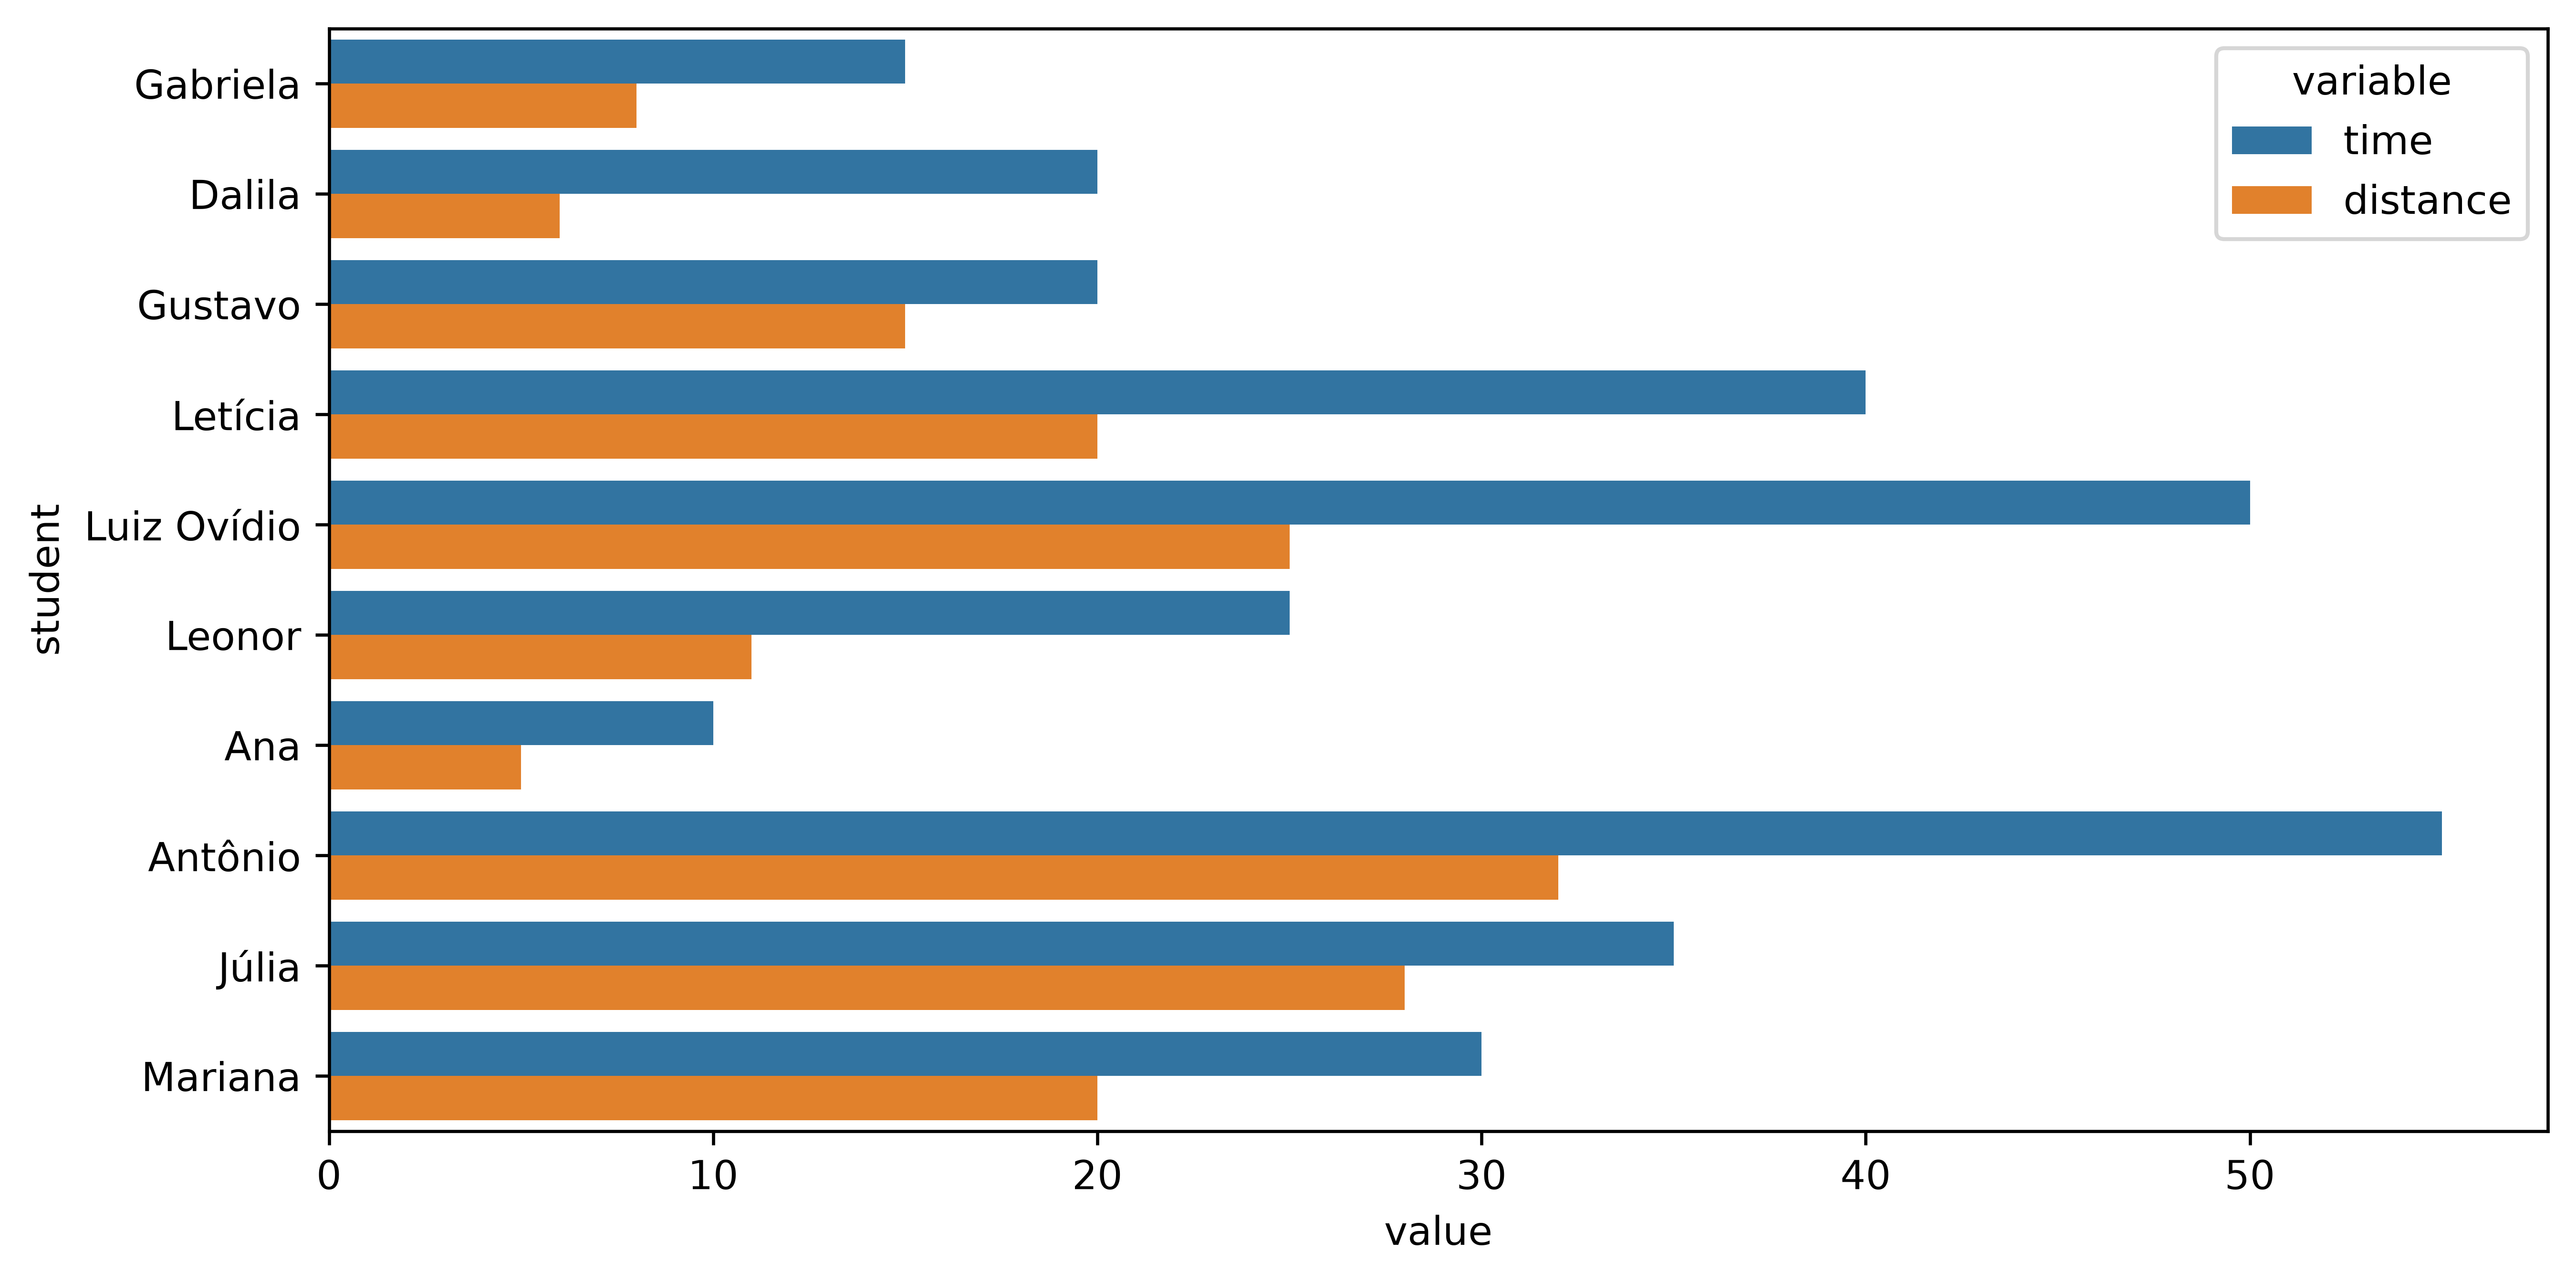

In [93]:
plt.figure(figsize=(10,5), dpi = 600)
sns.barplot(data=time_distance_melted, y='student', x='value', hue='variable')
plt.show()

# putting that into a sample graph

In [95]:
(time_data
.assign(traffic_lights_per_km = round((time_data['traffic_lights']/time_data['distance']), 2))
.query('time >= 30')
.rename(columns={'period':'per'})
.groupby('per')
.agg({'traffic_lights_per_km':'mean',
      'distance': 'mean',
      'per': 'count'}))

# chainned methods (functional programing)

,traffic_lights_per_km,distance,per
per,,,
Afternoon,0.073333,25.666667,3
Morning,0.045000,24.000000,2
